In [ ]:
def fetch_image_data():
    # TODO§
    return

In [46]:
from pathlib import Path

IMAGES_PATH = Path("../resources/cloud-images/CCSN_v2")

def index_labeled_images(images_path=IMAGES_PATH):
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }

    return labeled_images

In [90]:
labeled_images = index_labeled_images()

print(labeled_images)

{'Ac-N001.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N001.jpg'}, 'Ac-N002.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N002.jpg'}, 'Ac-N003.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N003.jpg'}, 'Ac-N004.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N004.jpg'}, 'Ac-N005.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N005.jpg'}, 'Ac-N006.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N006.jpg'}, 'Ac-N007.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N007.jpg'}, 'Ac-N008.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N008.jpg'}, 'Ac-N009.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N009.jpg'}, 'Ac-N010.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac-N010.jpg'}, 'Ac-N011.jpg': {'label': 'Ac', 'path': '../resources/cloud-images/CCSN_v2/Ac/Ac

In [93]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

def extract_labels(labeled_images):
    images = []
    labels = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        image = cv2.imread(path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (64, 64))
        images.append(image)

        label = labeled_images[image_name]['label']
        labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
images, labels = extract_labels(labeled_images)

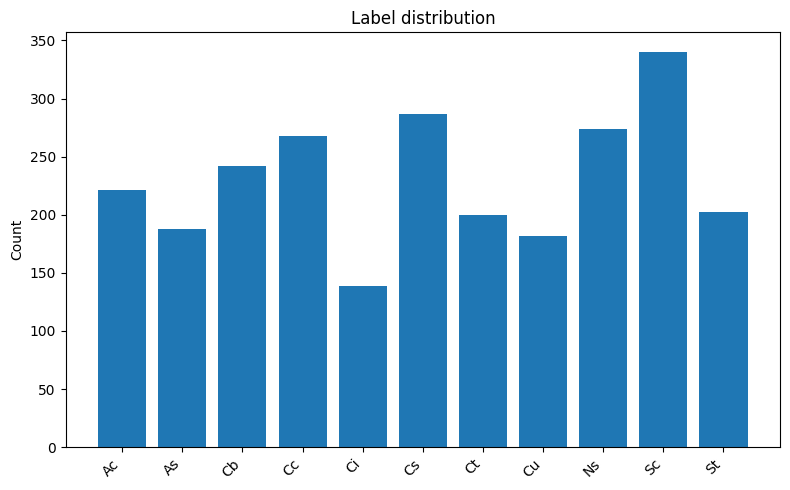

In [96]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Label distribution")
plt.tight_layout()
plt.show()